# Compositing and Matting Practice

## Mục tiêu bài tập

Bài tập này thực hành hai khái niệm chính trong xử lý ảnh:

- **Matting**: tách đối tượng chính ra khỏi ảnh và tạo **alpha matte**.
- **Compositing**: dùng alpha matte để ghép đối tượng đó sang một nền mới.

Trong bài này, ta có hai ảnh:

- Ảnh chứa mặt trăng: dùng làm **foreground source**.
- Ảnh texture/nền mới: dùng làm **background**.

---

## Ý tưởng chính

Một ảnh compositing thường được mô hình hóa bằng công thức:

$$
C = \alpha F + (1 - \alpha)BKagurabachi
$$

Trong đó:

- $C$: ảnh kết quả sau khi ghép.
- $F$: foreground, tức đối tượng cần giữ lại.
- $B$: background mới.
- $\alpha$: alpha matte, thể hiện mức độ đóng góp của foreground tại từng pixel.

Giá trị của $\alpha$:

- $\alpha = 1$: pixel hoàn toàn thuộc foreground.
- $\alpha = 0$: pixel hoàn toàn thuộc background.
- $0 < \alpha < 1$: pixel nằm ở vùng biên mềm hoặc bán trong suốt.

---

## Các bước thực hiện

1. Đọc ảnh foreground và background.
2. Dùng **GrabCut** để tạo mask thô cho mặt trăng.
3. Chuyển mask thành **alpha matte**.
4. Làm sạch mask bằng morphology.
5. Làm mềm biên mask bằng Gaussian Blur.
6. Resize background để cùng kích thước với ảnh foreground.
7. Ghép ảnh theo công thức:

$$
C = \alpha F + (1 - \alpha)B
$$

---

## Ý nghĩa bài tập

Bài tập này giúp hiểu rằng:

- **Matting** không chỉ là cắt đối tượng bằng mask cứng.
- Alpha matte có thể có giá trị liên tục từ 0 đến 1 để tạo vùng biên tự nhiên.
- **Compositing** là bước dùng alpha matte để ghép foreground vào background mới.
- Nếu alpha matte càng tốt thì ảnh ghép càng tự nhiên.

Trong ví dụ này, ảnh không có nền xanh nên việc tách mặt trăng khó hơn chroma key. Vì vậy ta dùng GrabCut để ước lượng foreground/background dựa trên vùng chọn ban đầu.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Foreground: (3455, 5182, 3)
Background: (3648, 5472, 3)


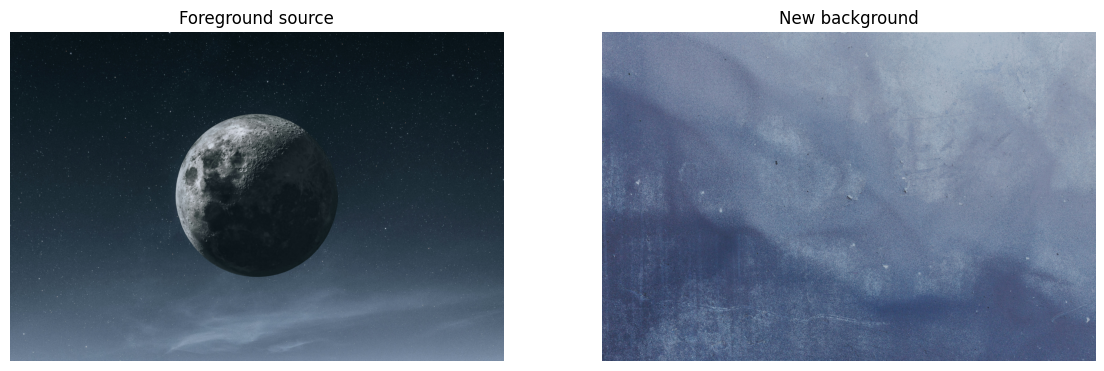

In [2]:
fg_path = "dataset/img_2.jpg"   # ảnh có mặt trăng
bg_path = "dataset/img_3.jpg"   # background mới

fg_bgr = cv2.imread(fg_path)
bg_bgr = cv2.imread(bg_path)

fg_rgb = cv2.cvtColor(fg_bgr, cv2.COLOR_BGR2RGB)
bg_rgb = cv2.cvtColor(bg_bgr, cv2.COLOR_BGR2RGB)

print("Foreground:", fg_rgb.shape)
print("Background:", bg_rgb.shape)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(fg_rgb)
plt.title("Foreground source")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(bg_rgb)
plt.title("New background")
plt.axis("off")

plt.show()

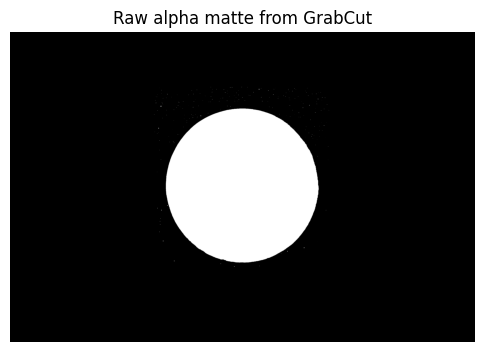

In [3]:
# Tạo mask thô cho mặt trăng bằng GrabCut

img = fg_bgr.copy()
h, w = img.shape[:2]

# Rectangle bao quanh mặt trăng
# Format: x, y, width, height
rect = (
    int(w * 0.31),   # x
    int(h * 0.18),   # y
    int(w * 0.38),   # width
    int(h * 0.58)    # height
)

mask = np.zeros((h, w), np.uint8)

bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

cv2.grabCut(
    img,
    mask,
    rect,
    bgdModel,
    fgdModel,
    5,
    cv2.GC_INIT_WITH_RECT
)

# GrabCut trả về nhiều nhãn:
# 0 = sure background
# 1 = sure foreground
# 2 = probable background
# 3 = probable foreground
alpha_raw = np.where(
    (mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD),
    1,
    0
).astype(np.float32)

plt.figure(figsize=(6, 6))
plt.imshow(alpha_raw, cmap="gray")
plt.title("Raw alpha matte from GrabCut")
plt.axis("off")
plt.show()

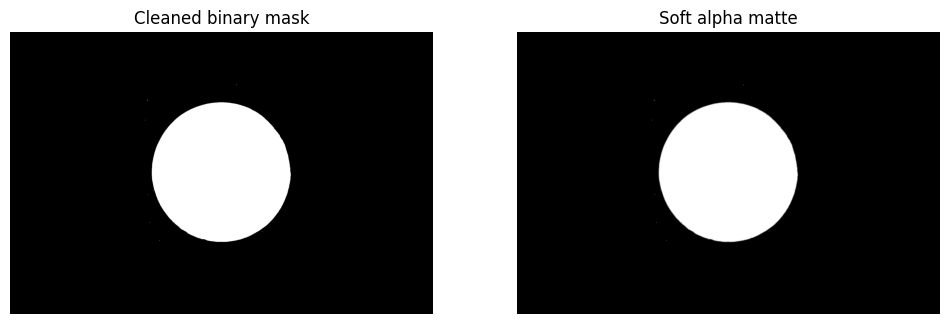

In [37]:
# Làm sạch và làm mềm alpha matte

alpha = alpha_raw.copy()

# Morphology để loại nhiễu nhỏ
kernel = np.ones((5, 5), np.uint8)

alpha_uint8 = (alpha * 255).astype(np.uint8)
alpha_uint8 = cv2.morphologyEx(alpha_uint8, cv2.MORPH_OPEN, kernel)
alpha_uint8 = cv2.morphologyEx(alpha_uint8, cv2.MORPH_CLOSE, kernel)

# Làm mềm biên bằng Gaussian blur
alpha_blur = cv2.GaussianBlur(alpha_uint8, (21, 21), 0)

# Chuẩn hóa về 0 -> 1
alpha = alpha_blur.astype(np.float32) / 255.0

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(alpha_uint8, cmap="gray")
plt.title("Cleaned binary mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(alpha, cmap="gray")
plt.title("Soft alpha matte")
plt.axis("off")

plt.show()

In [40]:
# Extract foreground bằng alpha matte

fg_float = fg_rgb.astype(np.float32) / 255.0
alpha_3 = alpha[:, :, None]

foreground_extracted = fg_float * alpha_3


# Resize background cho cùng kích thước foreground

bg_resized = cv2.resize(bg_rgb, (w, h))
bg_float = bg_resized.astype(np.float32) / 255.0


# Compositing

composite = alpha_3 * fg_float + (1 - alpha_3) * bg_float
composite = np.clip(composite, 0, 1)

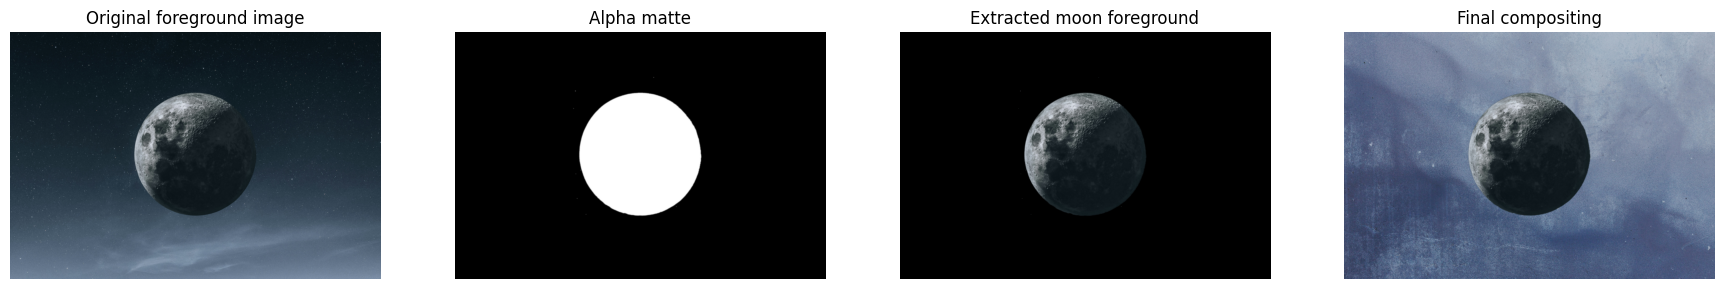

In [41]:
plt.figure(figsize=(22, 6))

plt.subplot(1, 4, 1)
plt.imshow(fg_rgb)
plt.title("Original foreground image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(alpha, cmap="gray")
plt.title("Alpha matte")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(foreground_extracted)
plt.title("Extracted moon foreground")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(composite)
plt.title("Final compositing")
plt.axis("off")

plt.show()

# Invert Gamma Mapping Practice

## Mục tiêu bài tập

Bài tập này thực hành **invert gamma mapping** trên một ảnh tự nhiên.

Trong xử lý ảnh, nhiều ảnh thông thường như JPEG/PNG thường không lưu giá trị pixel theo ánh sáng tuyến tính tuyệt đối. Thay vào đó, ảnh thường đã được **gamma encoded** để phù hợp hơn với cách mắt người cảm nhận độ sáng và cách ảnh được hiển thị trên màn hình.

Bài tập này giúp quan sát sự khác nhau giữa:

- ảnh gamma-encoded dùng để hiển thị,
- ảnh sau khi invert gamma, gần hơn với miền **linear light**,
- ảnh được gamma encode lại để hiển thị bình thường.

---

## Ý tưởng chính

Giả sử ảnh đầu vào có giá trị pixel đã chuẩn hóa về khoảng:

$$0 \leq f(x) \leq 1$$

Nếu ảnh đang ở dạng gamma-encoded, ta có thể đưa nó về miền linear light bằng:

$$
g(x) = [f(x)]^\gamma
$$

Trong đó:

- $f(x)$: giá trị pixel ban đầu.
- $g(x)$: giá trị pixel sau khi invert gamma.
- $\gamma$: hệ số gamma, thường thử với giá trị khoảng $2.2$ cho ảnh thông thường.

Sau khi xử lý trong miền linear light, nếu muốn hiển thị ảnh trở lại bình thường, ta gamma encode lại bằng:

$$
f_{display}(x) = [g(x)]^{1/\gamma}
$$

---

## Các bước thực hiện

1. Đọc ảnh đầu vào.
2. Chuyển ảnh từ BGR sang RGB để hiển thị đúng màu.
3. Chuẩn hóa giá trị pixel từ khoảng $[0, 255]$ về $[0, 1]$.
4. Áp dụng invert gamma:

$$
g(x) = [f(x)]^\gamma
$$

5. Quan sát ảnh sau invert gamma.
6. Gamma encode ảnh lại bằng:

$$
f_{display}(x) = [g(x)]^{1/\gamma}
$$

7. So sánh ảnh gốc, ảnh linear-light và ảnh encode lại.
8. Quan sát histogram để thấy phân bố intensity thay đổi như thế nào.

---

## Ý nghĩa bài tập

Bài tập này giúp hiểu rằng:

- Ảnh dùng để hiển thị thường không giống hoàn toàn với dữ liệu ánh sáng tuyến tính.
- Invert gamma thường làm ảnh nhìn tối hơn khi hiển thị trực tiếp.
- Ảnh linear-light phù hợp hơn cho một số phép tính vật lý như blending, compositing, lighting hoặc intensity analysis.
- Sau khi xử lý trong miền linear-light, cần gamma encode lại để ảnh hiển thị tự nhiên trên màn hình.

Nói ngắn gọn:

```text
Gamma-encoded image → phù hợp để hiển thị
Linear-light image → phù hợp để xử lý/tính toán

Image shape: (6002, 9000, 3)
dtype: uint8
min: 0 max: 255


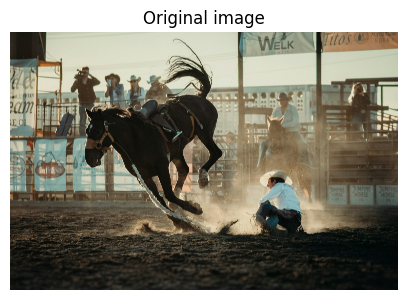

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "dataset/img_1.jpg"

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Image shape:", img_rgb.shape)
print("dtype:", img_rgb.dtype)
print("min:", img_rgb.min(), "max:", img_rgb.max())

plt.figure(figsize=(5,5))
plt.imshow(img_rgb)
plt.title("Original image")
plt.axis("off")
plt.show()

In [9]:
# Chuẩn hóa ảnh về khoảng [0, 1]

img = img_rgb.astype(np.float32) / 255.0

print("After normalization")
print("dtype:", img.dtype)
print("min:", img.min(), "max:", img.max())

After normalization
dtype: float32
min: 0.0 max: 1.0


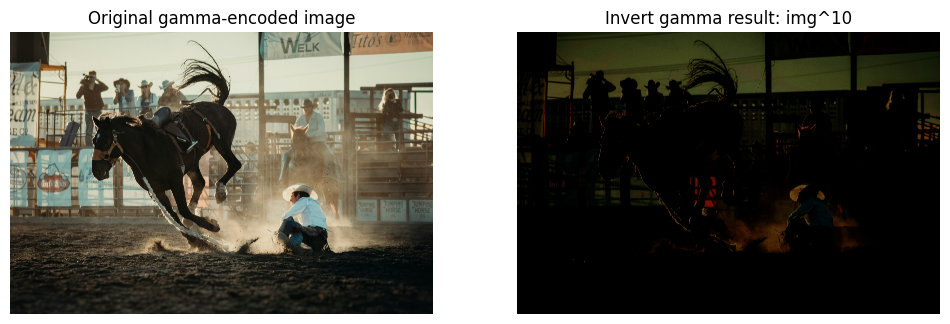

In [12]:
# Invert gamma mapping

gamma = 10

linear_img = np.power(img, gamma)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original gamma-encoded image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(linear_img)
plt.title(f"Invert gamma result: img^{gamma}")
plt.axis("off")

plt.show()

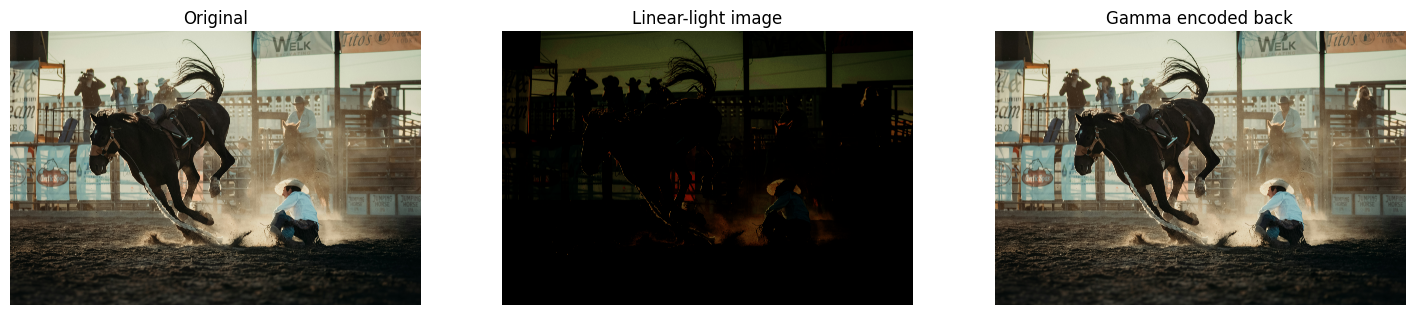

In [14]:
# Gamma encode lại để hiển thị

encoded_back = np.power(linear_img, 1 / gamma)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(linear_img)
plt.title("Linear-light image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(encoded_back)
plt.title("Gamma encoded back")
plt.axis("off")

plt.show()

# Histogram Equalization and Contrast Stretching Practice

## Mục tiêu bài thực hành

Bài thực hành này áp dụng hai kỹ thuật tăng tương phản ảnh grayscale:

- **Contrast Stretching**
- **Histogram Equalization**

Ảnh đầu vào là một ảnh phong cảnh grayscale có độ tương phản chưa cao. Nhiều mức sáng trong ảnh tập trung ở một khoảng hẹp, làm ảnh nhìn hơi nhạt và thiếu độ nổi bật giữa vùng sáng, vùng tối.

Mục tiêu là quan sát cách hai phương pháp thay đổi phân bố intensity và cải thiện contrast của ảnh.

---

## 1. Contrast Stretching

**Contrast Stretching** là kỹ thuật kéo giãn dải giá trị pixel của ảnh.

Nếu ảnh ban đầu chỉ có intensity nằm trong khoảng:

$$
f_{min} \rightarrow f_{max}
$$

ta ánh xạ khoảng đó ra toàn bộ dải:

$$
0 \rightarrow 255
$$

Công thức:

$$
g(x) = \frac{f(x) - f_{min}}{f_{max} - f_{min}} \times 255
$$

Trong đó:

- $f(x)$: giá trị pixel ban đầu.
- $g(x)$: giá trị pixel sau khi stretching.
- $f_{min}$: intensity nhỏ nhất trong ảnh.
- $f_{max}$: intensity lớn nhất trong ảnh.

Kỹ thuật này là một phép biến đổi **tuyến tính**. Nó giữ thứ tự sáng tối giữa các pixel nhưng kéo rộng khoảng intensity để ảnh có tương phản cao hơn.

---

## 2. Percentile Contrast Stretching

Dùng min/max tuyệt đối đôi khi bị ảnh hưởng bởi một vài pixel quá tối hoặc quá sáng.

Vì vậy, ta có thể dùng percentile, ví dụ:

$$
2\% \rightarrow 98\%
$$

Thay vì dùng pixel nhỏ nhất và lớn nhất tuyệt đối, ta dùng ngưỡng thấp và ngưỡng cao dựa trên phân vị. Cách này thường ổn định hơn trong thực tế.

---

## 3. Histogram Equalization

**Histogram Equalization** là kỹ thuật cân bằng histogram để phân bố lại intensity của ảnh.

Khác với Contrast Stretching, Histogram Equalization là phép biến đổi **phi tuyến**. Nó dựa trên histogram và hàm phân phối tích lũy, gọi là **CDF**.

Ý tưởng:

- Nếu nhiều pixel tập trung ở một vùng intensity hẹp, vùng đó sẽ được kéo giãn ra.
- Các mức sáng được phân bố lại để ảnh có độ tương phản tốt hơn.
- Kết quả thường làm chi tiết trong ảnh rõ hơn, đặc biệt với ảnh có contrast thấp.

---

## 4. So sánh hai phương pháp

| Phương pháp | Loại biến đổi | Đặc điểm |
|---|---|---|
| Contrast Stretching | Tuyến tính | Kéo dải intensity từ khoảng hẹp ra 0–255 |
| Percentile Stretching | Tuyến tính có clipping | Ít bị ảnh hưởng bởi outlier hơn min-max stretching |
| Histogram Equalization | Phi tuyến | Phân bố lại intensity dựa trên histogram/CDF |

---

## 5. Các bước thực hiện

1. Đọc ảnh grayscale.
2. Hiển thị ảnh gốc và histogram ban đầu.
3. Áp dụng Contrast Stretching bằng min-max.
4. Áp dụng Contrast Stretching bằng percentile.
5. Áp dụng Histogram Equalization.
6. So sánh ảnh kết quả.
7. So sánh histogram trước và sau xử lý.
8. Quan sát CDF để hiểu cách Histogram Equalization thay đổi phân bố intensity.

---

## Ý nghĩa bài thực hành

Bài thực hành này giúp hiểu rằng tăng contrast không chỉ là làm ảnh sáng hơn hoặc tối hơn. Quan trọng hơn là cách phân bố lại các mức intensity để vùng sáng, vùng tối và chi tiết ảnh được phân biệt rõ hơn.

Nói ngắn gọn:

```text
Contrast Stretching = kéo rộng dải intensity
Histogram Equalization = cân bằng lại phân bố intensity

Image shape: (424, 640)
dtype: uint8
min: 0
max: 250


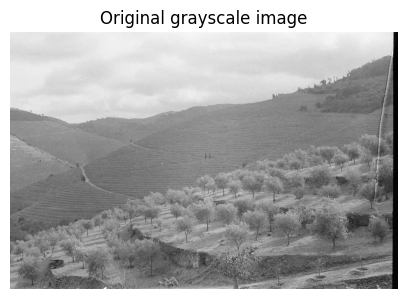

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "dataset/img_4.jpg"

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

print("Image shape:", img.shape)
print("dtype:", img.dtype)
print("min:", img.min())
print("max:", img.max())

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title("Original grayscale image")
plt.axis("off")
plt.show()

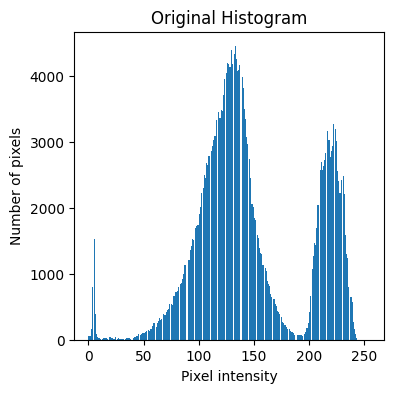

In [28]:
plt.figure(figsize=(4, 4))
plt.hist(img.ravel(), bins=256, range=(0, 256))
plt.title("Original Histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.show()

Original min/max: 0 250
Contrast stretched min/max: 0 255
Percentile low/high: 59.0 233.0
Percentile stretched min/max: 0 255


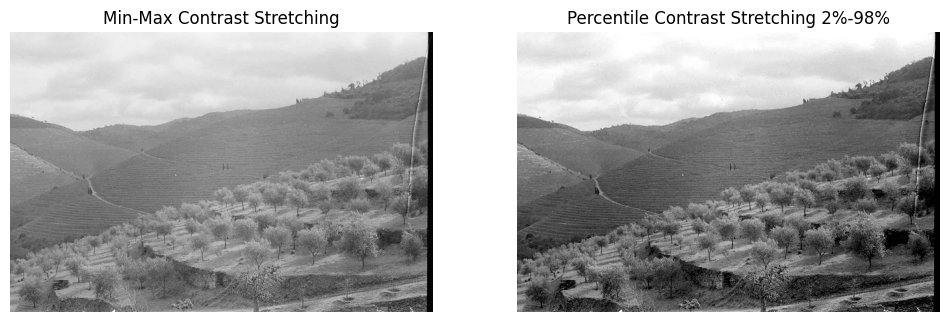

In [26]:
# Contrast Stretching

# Min-Max Contrast Stretching

f_min = img.min()
f_max = img.max()

contrast_stretched = (img.astype(np.float32) - f_min) / (f_max - f_min) * 255
contrast_stretched = np.clip(contrast_stretched, 0, 255).astype(np.uint8)

print("Original min/max:", f_min, f_max)
print("Contrast stretched min/max:", contrast_stretched.min(), contrast_stretched.max())

# Percentile Contrast Stretching

low, high = np.percentile(img, (2, 98))

contrast_stretched_p = (img.astype(np.float32) - low) / (high - low) * 255
contrast_stretched_p = np.clip(contrast_stretched_p, 0, 255).astype(np.uint8)

print("Percentile low/high:", low, high)
print("Percentile stretched min/max:", contrast_stretched_p.min(), contrast_stretched_p.max())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(contrast_stretched, cmap="gray")
plt.title("Min-Max Contrast Stretching")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(contrast_stretched_p, cmap="gray")
plt.title("Percentile Contrast Stretching 2%-98%")
plt.axis("off")

plt.show()

Histogram equalized min/max: 0 255


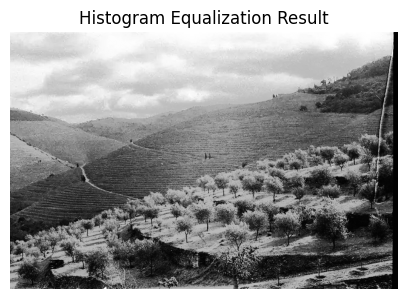

In [29]:
# Histogram Equalization

hist_equalized = cv2.equalizeHist(img)

print("Histogram equalized min/max:", hist_equalized.min(), hist_equalized.max())

plt.figure(figsize=(5, 5))
plt.imshow(hist_equalized, cmap="gray")
plt.title("Histogram Equalization Result")
plt.axis("off")
plt.show()

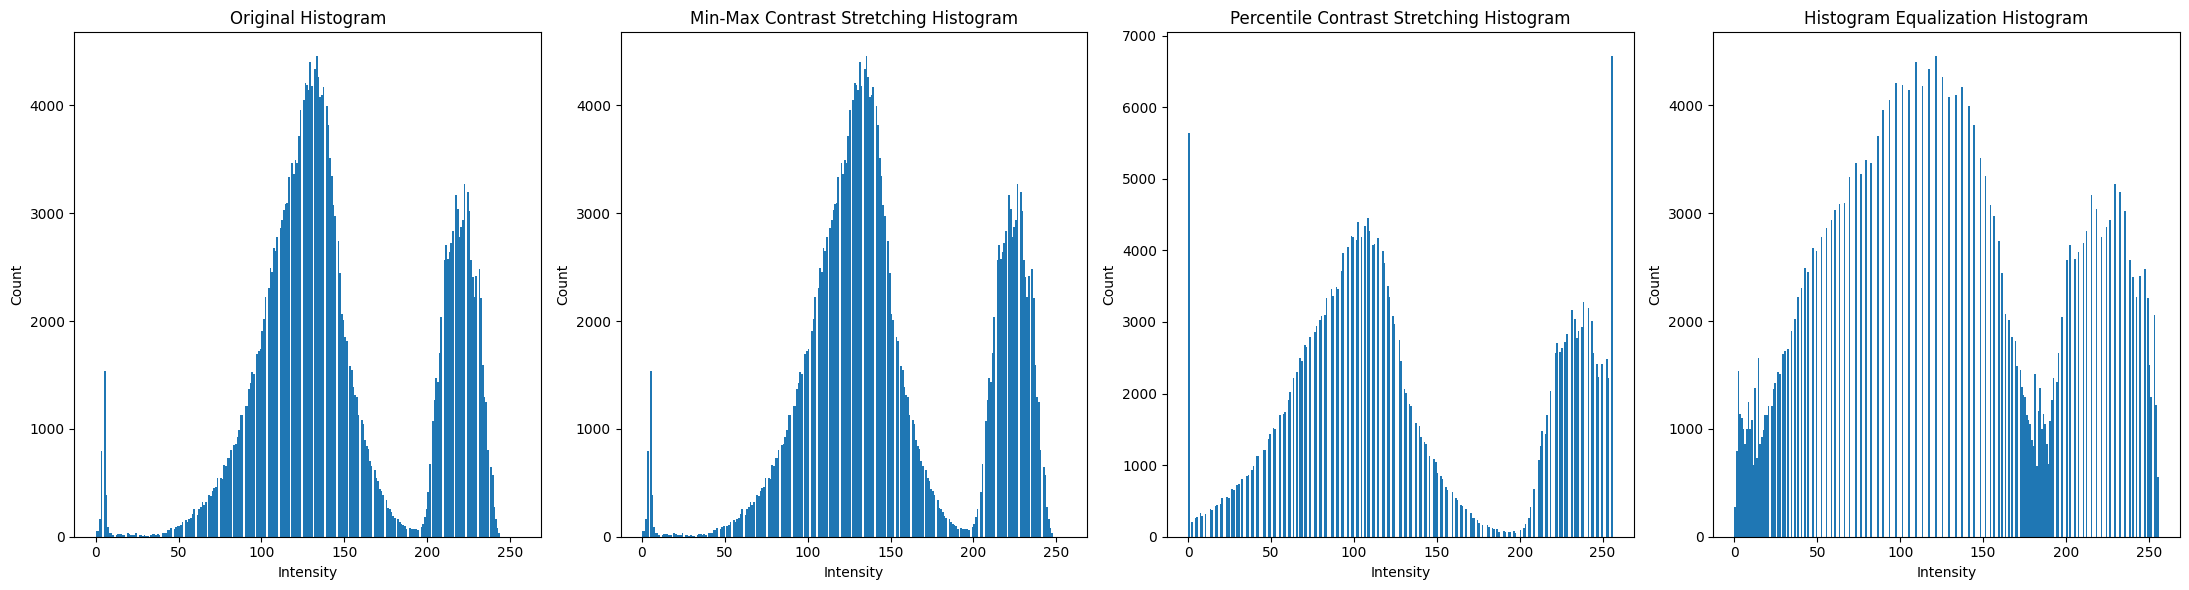

In [25]:
# So sánh histogram

plt.figure(figsize=(22, 6))

plt.subplot(1, 4, 1)
plt.hist(img.ravel(), bins=256, range=(0, 256))
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Count")

plt.subplot(1, 4, 2)
plt.hist(contrast_stretched.ravel(), bins=256, range=(0, 256))
plt.title("Min-Max Contrast Stretching Histogram")
plt.xlabel("Intensity")
plt.ylabel("Count")

plt.subplot(1, 4, 3)
plt.hist(contrast_stretched_p.ravel(), bins=256, range=(0, 256))
plt.title("Percentile Contrast Stretching Histogram")
plt.xlabel("Intensity")
plt.ylabel("Count")

plt.subplot(1, 4, 4)
plt.hist(hist_equalized.ravel(), bins=256, range=(0, 256))
plt.title("Histogram Equalization Histogram")
plt.xlabel("Intensity")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

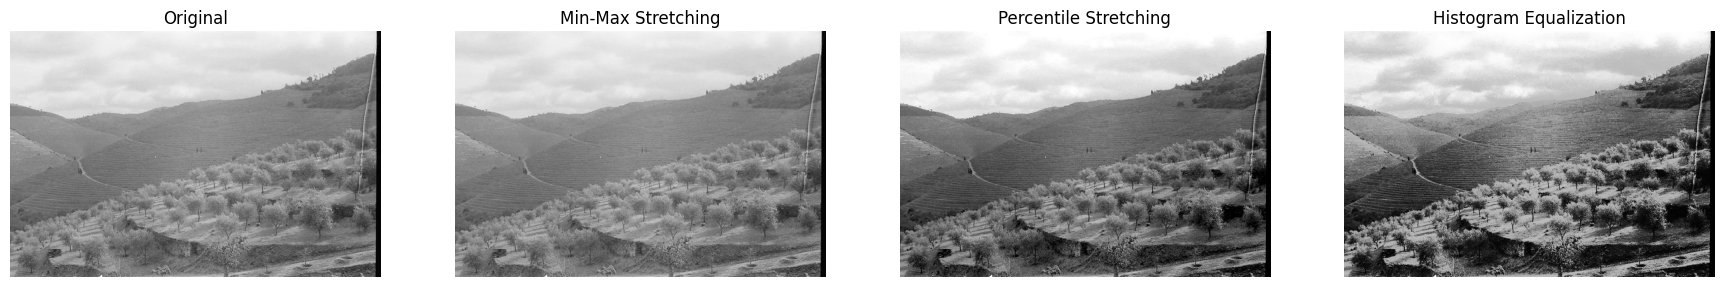

In [23]:
# So sánh tất cả kết quả
plt.figure(figsize=(22, 6))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(contrast_stretched, cmap="gray")
plt.title("Min-Max Stretching")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(contrast_stretched_p, cmap="gray")
plt.title("Percentile Stretching")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(hist_equalized, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")

plt.show()

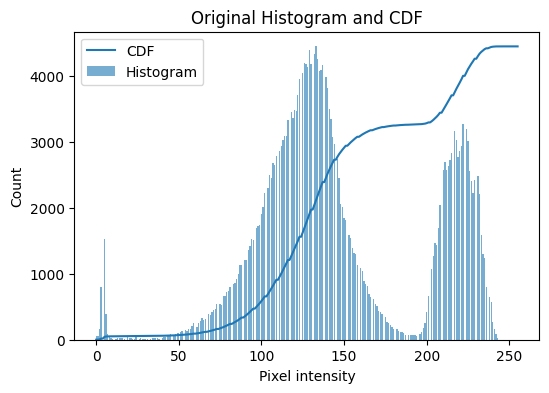

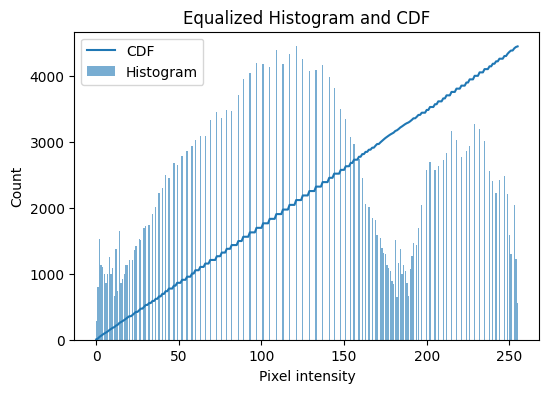

In [31]:
# Vẽ cumulative distribution function, CDF

def plot_hist_and_cdf(image, title):
    hist, bins = np.histogram(image.ravel(), bins=256, range=(0, 256))
    cdf = hist.cumsum()
    cdf_normalized = cdf / cdf.max()

    plt.figure(figsize=(6, 4))

    plt.bar(np.arange(256), hist, alpha=0.6, label="Histogram")
    plt.plot(cdf_normalized * hist.max(), label="CDF")
    
    plt.title(title)
    plt.xlabel("Pixel intensity")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

plot_hist_and_cdf(img, "Original Histogram and CDF")
plot_hist_and_cdf(hist_equalized, "Equalized Histogram and CDF")

# Thresholding Practice

## Mục tiêu bài thực hành

Bài thực hành này giúp hiểu kỹ thuật **thresholding** trong xử lý ảnh.

Thresholding là phương pháp biến đổi ảnh grayscale thành ảnh nhị phân, trong đó mỗi pixel chỉ có hai giá trị:

- Đen: \(0\)
- Trắng: \(255\)

Ý tưởng chính:

$$
g(x, y) =
\begin{cases}
0, & \text{nếu } I(x, y) < T \\
255, & \text{nếu } I(x, y) \geq T
\end{cases}
$$


Trong đó:

- \(I(x, y)\): intensity của pixel tại vị trí \((x, y)\)
- \(T\): ngưỡng threshold
- \(g(x, y)\): pixel kết quả sau thresholding

---

## Ý nghĩa

Thresholding thường được dùng để:

- tách foreground/background,
- tạo binary mask,
- phân đoạn vật thể đơn giản,
- tiền xử lý cho contour detection,
- tách vùng sáng/tối trong ảnh.

Nếu chọn ngưỡng \(T\) phù hợp, các vùng quan tâm sẽ được tách rõ khỏi nền.

---

## Các kỹ thuật trong bài

1. Manual thresholding bằng NumPy.
2. Thresholding bằng OpenCV.
3. Thử nhiều giá trị threshold khác nhau.
4. Quan sát histogram để chọn threshold.
5. Otsu thresholding để tự động tìm ngưỡng. (Otsu là phương pháp tự động chọn threshold dựa trên histogram.)

In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(2216, 4032)
uint8
0
248


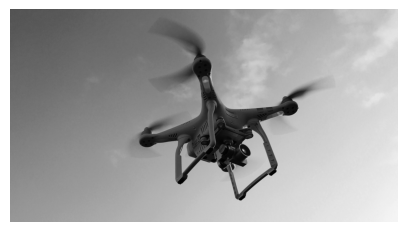

In [48]:
img_path = "dataset/img_5.jpg"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

print(img.shape)
print(img.dtype)
print(img.min())
print(img.max())

plt.figure(figsize=(5,5))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

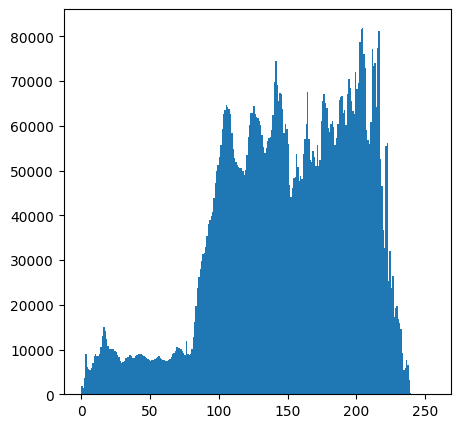

In [65]:
# Visualize histogram to choose threshold

plt.figure(figsize=(5,5))
plt.hist(img.ravel(), bins=256, range=(0,256))
plt.show()

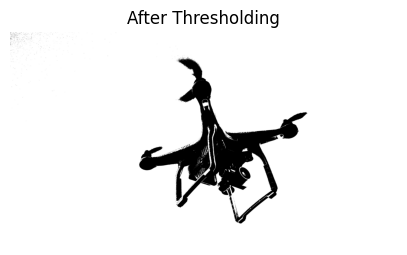

In [66]:
# Threshold by Numpy

threshold = 78
result_thrs = np.where(img > threshold, 255, 0).astype(np.uint8)

plt.figure(figsize=(5,5))
plt.imshow(result_thrs, cmap="gray")
plt.title("After Thresholding")
plt.axis("off")
plt.show()

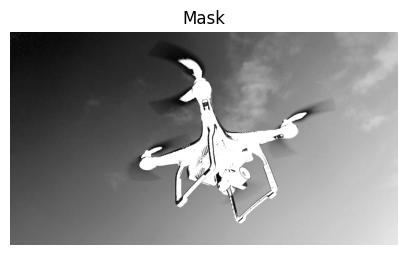

In [78]:
# Mask by Numpy

mask = img < threshold

result_mask = img.copy()
result_mask[mask] = 255

plt.figure(figsize=(5,5))
plt.imshow(result_mask, cmap="gray")
plt.title("Mask")
plt.axis("off")
plt.show()

Threshold used: 78.0


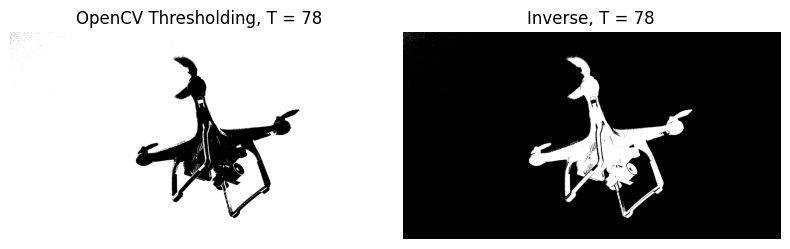

In [75]:
ret_upr, binary_cv_upr = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY)
ret_inv, binary_cv_inv = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY_INV)

print("Threshold used:", ret)

plt.figure(figsize=(8, 4))
plt.subplot(1,2,1)
plt.imshow(binary_cv_upr, cmap="gray")
plt.title(f"OpenCV Thresholding, T = {threshold}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(binary_cv_inv, cmap="gray")
plt.title(f"Inverse, T = {threshold}")
plt.axis("off")

plt.tight_layout()
plt.show()

Otsu threshold: 146.0


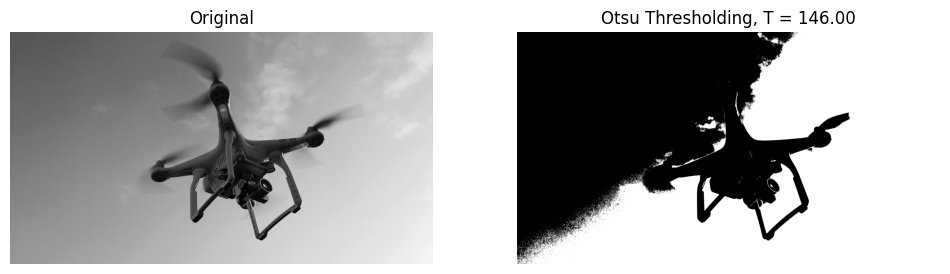

In [77]:
# Otsu Thresholding

otsu_T, binary_otsu = cv2.threshold(
    img,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu threshold:", otsu_T)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary_otsu, cmap="gray")
plt.title(f"Otsu Thresholding, T = {otsu_T:.2f}")
plt.axis("off")

plt.show()